# Verification of simulation subpackage. Part 1: Computing integral quantities for x-ray qualities.

Tools provided by MetPyX:

- **Spectrum class**: Represents an X-ray spectrum built on top of `spekpy.Spek` and provides utilities to compute:
    - Mean air-kerma-to-dose conversion coefficient.
    - Dose equivalent for a given operational quantity and irradiation angle.
- **Quality class**: Represents an X-ray quality built on top of `metpyx.sim.Spectrum` and allows to initialize a Spectrum instance from a named X-ray quality.

In [1]:
# Importing libraries
import warnings
import numpy as np
import pandas as pd
import spekpy as sp
import uspekpy as usp
from matplotlib import pyplot as plt
from scipy.interpolate import Akima1DInterpolator
from metpyx.sim import Spectrum, Quality
from metpyx.data import Qualities, OperationalQuantities

## Reference case verification

Reference case for verification:

- N60 radiation quality.
- Anode angle of 20º.
- H*(10) operational quantity at 0º irradiation angle.
- mass energy transfer coefficients for air from PENELOPE 2018.
- air kerma to dose conversion coefficients from CMI 2025.
- measurement distance at 1 m.
- air thickness equal to distance.

### Using SpekPy

In [2]:
# Dictionary to store results
r_spek_cls = {}

In [3]:
# Spek instance initialization
s = sp.Spek(kvp=60, th=20)
s.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 1000]])

In [4]:
# Get the spectrum (use diff=False to get non-differential fluence values (1/cm²), which are needed for the mean conversion coefficient calculation)
r_spek_cls['spectrum'] = s.get_spectrum(diff=False)

In [5]:
# Get quality related integral quantities (not related to dose)
r_spek_cls['e_mean'] = s.get_emean()  # keV
r_spek_cls['kerma'] = s.get_kerma()  # uGy
r_spek_cls['hvl1_al'] = s.get_hvl1()  # mm
r_spek_cls['hvl2_al'] = s.get_hvl2()  # mm
r_spek_cls['hvl1_cu'] = s.get_hvl1(matl="Cu")  # mm
r_spek_cls['hvl2_cu'] = s.get_hvl2(matl="Cu")  # mm

In [6]:
# Get mean conversion coefficient calculation

# Define mass energy transfer coefficients for air (PENELOPE 2018). Units (keV, cm²/g)
pene_2018_energies = [
    1.0, 1.1726, 1.25, 1.4, 1.5, 1.75, 2.0, 2.5, 3.0, 3.2063, 3.206301, 3.22391, 3.25051, 3.5, 3.61881, 4.0,
    5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.5, 14.0, 15.0, 17.5, 20.0, 25.0, 28.6633, 30.0, 35.0, 40.0, 50.0, 60.0,
    70.0, 80.0, 90.0, 100.0, 125.0, 140.0, 150.0, 175.0, 187.083, 200.0, 250.0, 300.0, 324.037, 350.0, 386.867,
    400.0, 474.342, 500.0, 574.456, 600.0, 673.537, 700.0, 800.0, 900.0, 1000.0, 1250.0, 1500.0, 1558.93,
    1750.0, 1870.83, 2000.0, 2345.21, 2500.0, 3000.0, 3240.37, 3500.0, 4000.0, 4500.0, 5000.0, 6000.0, 6480.74,
    7000.0, 8000.0, 9000.0
]
pene_2018_values = [
    3487.7, 2271.66, 1907.85, 1396.25, 1152.41, 746.85, 510.495, 267.712, 156.677, 128.597, 139.322, 139.22,
    136.749, 110.244, 99.9467, 74.3863, 38.3165, 22.1387, 13.8638, 9.20954762864289, 6.40746485225397,
    4.62692014996195, 2.30743153037744, 1.61505075253763, 1.30130979037554, 0.801145676760343,
    0.525990443101652, 0.262079759969996, 0.17213944380102, 0.150643910752649, 0.096166283094939,
    0.067006659158694, 0.040350724533314, 0.030060380204255, 0.025736225862943, 0.023919178948042,
    0.023273564441493, 0.023169137685326, 0.023905175732908, 0.024501233602389, 0.024926643691358,
    0.025877217107796, 0.026274062287156, 0.026655131026205, 0.027882238669658, 0.028683812435718,
    0.028972447929017, 0.029148771809045, 0.029415131704691, 0.029490249846129, 0.029698178702551,
    0.029685041261757, 0.029603764611649, 0.029549718949812, 0.029405101930449, 0.029197657857256,
    0.028890614121642, 0.028390536220701, 0.027936798166738, 0.026719405747041, 0.02562121786982,
    0.025359438553807, 0.02463108715039, 0.024240842040503, 0.023753744772526, 0.022671649894621,
    0.022309768351513, 0.021132688079239, 0.020639133403572, 0.020121558259145, 0.019347638398287,
    0.018700741656237, 0.018185053120065, 0.017326066208925, 0.016966042150857, 0.016690444038446,
    0.016199645451199, 0.015809252632524
]

# Define air-kerma-to-dose conversion coefficients for H*(10) at 0º irradiation angle (CMI 2025). Units (keV, Sv/Gy)
cmi_2025_energies_h_star_10_0 = [
    2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40,
    42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 65, 70, 75, 80, 85, 90, 95, 100, 110, 120, 130, 140, 150, 160, 170,
    180, 190, 200, 225, 240, 250, 275, 300, 325, 350, 375, 400, 425, 450, 500, 511, 550, 600, 662, 700, 800,
    900, 1000, 1117, 1173, 1250, 1332, 1500, 1700, 1750, 2000, 2400, 2500, 3000, 3500, 4000, 4440, 5000, 6000,
    6129, 7000, 8000, 9000, 10000, 12500, 15000, 17500, 20000, 25000, 30000, 35000, 40000, 45000, 50000
]
cmi_2025_values_h_star_10_0 = [
    0.0, 0.0, 0.0, 0.0, 0.0, 5.006211183e-07, 7.53411188163e-05, 0.0013399279666727, 0.008339974116065,
    0.027959365493142, 0.0649015031392173, 0.117892384153277, 0.182854496500547, 0.254785065497812,
    0.329684376352027, 0.404237490435794, 0.474883646496535, 0.543075936619701, 0.608764764690923,
    0.729121699136139, 0.834359989357258, 0.932217912526701, 1.019787991814, 1.10127304871649, 1.17923580150499,
    1.25093929821867, 1.31693499152686, 1.37836679008758, 1.43614832274801, 1.48895147535783, 1.53695987736966,
    1.579367978262, 1.61683555911064, 1.65111364109003, 1.67895036865187, 1.70147532324998, 1.71959205780654,
    1.73569389238546, 1.7513548512875, 1.7660601751939, 1.76411105061724, 1.75880008458157, 1.74401588142437,
    1.7259083944068, 1.7051120882291, 1.68285949300524, 1.660806895852, 1.62069771752482, 1.58655624975128,
    1.55253890207103, 1.5214025670048, 1.49292559713724, 1.47191391445754, 1.45095250563087, 1.43234388256437,
    1.41504458319957, 1.40045048056932, 1.36708755516683, 1.35062396617274, 1.34112411144134, 1.31829850613254,
    1.29920469418009, 1.28280551309179, 1.26779645957562, 1.25550014309865, 1.24492592905825, 1.23453216595746,
    1.225707899164, 1.2113467185313, 1.20789939579853, 1.19806539226821, 1.18818337262196, 1.17653859236809,
    1.17219827416785, 1.16041231542684, 1.14984262965137, 1.14263898967494, 1.13414788332302, 1.13119321285273,
    1.12823105732118, 1.12464830688625, 1.11896627040591, 1.11357509036097, 1.11227237543666, 1.1077193167192,
    1.10088553317439, 1.09989918128124, 1.09354396763082, 1.08802563926124, 1.08425634507853, 1.07995815186229,
    1.07712879613375, 1.0702298390959, 1.06941454173716, 1.06406552317947, 1.05908367593344, 1.05411440308156,
    1.05022231792777, 1.04082044834368, 1.03355131530843, 1.02708988121954, 1.02235595808979, 1.01449765630958,
    1.00889446838262, 1.00286377763245, 1.00129856074053, 0.997193631804752, 0.996021011235643
]

# Get spectrum data
energies = np.array(r_spek_cls['spectrum'][0])
fluence = np.array(r_spek_cls['spectrum'][1])

# Get mass energy transfer coefficients for air
mu_energies = np.array(pene_2018_energies)
mu_values = np.array(pene_2018_values)

# Get air-kerma-to-dose conversion coefficients for H*(10) at 0º irradiation angle
hk_energies = np.array(cmi_2025_energies_h_star_10_0)
hk_values = np.array(cmi_2025_values_h_star_10_0)

# If there are zeros in the values of mass energy transfer coefficients for air or
# air-kerma-to-dose conversion coefficients, remove them to avoid log(0)
if np.any(mu_values == 0):
    mask_mu = mu_values != 0
    filtered_mu_energies = mu_energies[mask_mu]
    filtered_mu_values = mu_values[mask_mu]
    print("Warning: Zeros found in mu_tr_over_rho_air values. They have been removed for interpolation.")
else:
    filtered_mu_energies = mu_energies
    filtered_mu_values = mu_values

if np.any(hk_values == 0):
    mask_hk = hk_values != 0
    filtered_hk_energies = hk_energies[mask_hk]
    filtered_hk_values = hk_values[mask_hk]
    print("Warning: Zeros found in h_k values. They have been removed for interpolation.")
else:
    filtered_hk_energies = hk_energies
    filtered_hk_values = hk_values

# Interpolating mass energy transfer coefficients for air coefficients to spectrum energies
interpolator = Akima1DInterpolator(x=np.log(filtered_mu_energies), y=np.log(filtered_mu_values))
interpolated_mu = np.exp(interpolator(np.log(energies)))

# Interpolating air-kerma-to-dose conversion coefficients to spectrum energies
interpolator = Akima1DInterpolator(x=np.log(filtered_hk_energies), y=np.log(filtered_hk_values))
interpolated_hk = np.exp(interpolator(np.log(energies)))

# Check for NaN values in interpolated results
if np.any(np.isnan(interpolated_mu)):
    print("Warning: NaN values found in interpolated mu_tr_over_rho_air.")
if np.any(np.isnan(interpolated_hk)):
    print("Warning: NaN values found in interpolated h_k.")

# Calculating mean conversion coefficient (use np.nansum to ignore NaN values in the calculation)
# Numerator: sum(phi(E) * E * mu_tr_over_rho(E) * h_K(E)):  keV * (1/cm²) * (cm²/g) * (Sv/Gy) = (keV/g) * (Sv/Gy)
# Denominator: sum(phi(E) * E * mu_tr_over_rho(E)): keV * (1/cm²) * (cm²/g) = keV/g
# Mean h_K: (keV/g) * (Sv/Gy) / (keV/g) = Sv/Gy
hk_mean_numerator = np.nansum(fluence * energies * interpolated_mu * interpolated_hk)
hk_mean_denominator = np.nansum(fluence * energies * interpolated_mu)
r_spek_cls['hk_mean'] = hk_mean_numerator / hk_mean_denominator

In [7]:
# Get dose equivalent for H*(10) at 0º irradiation angle
# Units: H = h_K * K_air: uGy * Sv/Gy = uSv
r_spek_cls['dose'] = r_spek_cls['hk_mean'] * r_spek_cls['kerma']

### Using Spectrum class from MetPyX

In [8]:
# Using Quality class from metpyx

# Dictionary to store results
r_spectrum_cls = {}

# Quality definitions
ms = Spectrum(kvp=60, th=20)
ms.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 1000]])

# Get the spectrum
r_spectrum_cls['spectrum'] = ms.get_spectrum(diff=False)

# Get quality related integral quantities (not related to dose)
r_spectrum_cls['e_mean'] = ms.get_emean()
r_spectrum_cls['kerma'] = ms.get_kerma()
r_spectrum_cls['hvl1_al'] = ms.get_hvl1()
r_spectrum_cls['hvl2_al'] = ms.get_hvl2()
r_spectrum_cls['hvl1_cu'] = ms.get_hvl1(matl="Cu")
r_spectrum_cls['hvl2_cu'] = ms.get_hvl2(matl="Cu")

# Calculating mean conversion coefficient
r_spectrum_cls['hk_mean'] = ms.get_hk_mean('h_star_10', 0)

# Get dose equivalent
r_spectrum_cls['dose'] = ms.get_dose_equivalent('h_star_10', 0)

### Using Quality class from MetPyX

In [9]:
# Using Quality class from metpyx

# Dictionary to store results
r_quality_cls = {}

# Quality definitions
mq = Quality("N60", th=20)

# Get the spectrum
r_quality_cls['spectrum'] = mq.get_spectrum(diff=False)

# Get quality related integral quantities (not related to dose)
r_quality_cls['e_mean'] = mq.get_emean()
r_quality_cls['kerma'] = mq.get_kerma()
r_quality_cls['hvl1_al'] = mq.get_hvl1()
r_quality_cls['hvl2_al'] = mq.get_hvl2()
r_quality_cls['hvl1_cu'] = mq.get_hvl1(matl="Cu")
r_quality_cls['hvl2_cu'] = mq.get_hvl2(matl="Cu")

# Calculating mean conversion coefficient
r_quality_cls['hk_mean'] = mq.get_hk_mean('h_star_10', 0)

# Get dose equivalent
r_quality_cls['dose'] = mq.get_dose_equivalent('h_star_10', 0)

### Comparison

In [10]:
# Build DataFrame to compare results
# Build a DataFrame to compare spectrum values
df_spectrum = pd.DataFrame({
    'Spek E (keV)': r_spek_cls['spectrum'][0],
    'Spek F (1/cm²)': r_spek_cls['spectrum'][1],
    'Spectrum E (keV)': r_spectrum_cls['spectrum'][0],
    'Spectrum F (1/cm²)': r_spectrum_cls['spectrum'][1],
    'Quality E (keV)': r_quality_cls['spectrum'][0],
    'Quality F (1/cm²)': r_quality_cls['spectrum'][1],
})
# Create a DataFrame to compare integral quantities values
df_iqs = pd.DataFrame({'Spek': r_spek_cls, 'Spectrum': r_spectrum_cls, 'Quality': r_quality_cls})
df_iqs.drop('spectrum', axis=0, inplace=True)

In [11]:
# Print spectrum comparison DataFrame
df_spectrum

,Spek E (keV),Spek F (1/cm²),Spectrum E (keV),Spectrum F (1/cm²),Quality E (keV),Quality F (1/cm²)
0,1.25,0.000000,1.25,0.000000,1.25,0.000000
1,1.75,0.000000,1.75,0.000000,1.75,0.000000
2,2.25,0.000000,2.25,0.000000,2.25,0.000000
3,2.75,0.000000,2.75,0.000000,2.75,0.000000
4,3.25,0.000000,3.25,0.000000,3.25,0.000000
...,...,...,...,...,...,...
113,57.75,51598.111480,57.75,51598.111480,57.75,51598.111480
114,58.25,41869.724742,58.25,41869.724742,58.25,41869.724742
115,58.75,31528.941521,58.75,31528.941521,58.75,31528.941521
116,59.25,20641.682514,59.25,20641.682514,59.25,20641.682514


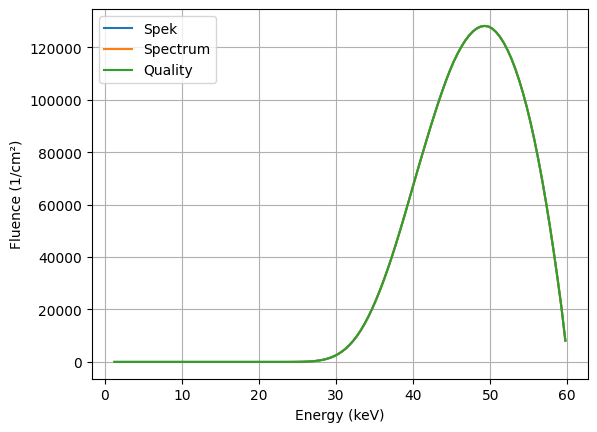

In [12]:
# Plot spectrum comparison
plt.figure()
plt.plot(r_spek_cls['spectrum'][0], r_spek_cls['spectrum'][1], label='Spek')
plt.plot(r_spectrum_cls['spectrum'][0], r_spectrum_cls['spectrum'][1], label='Spectrum')
plt.plot(r_quality_cls['spectrum'][0], r_quality_cls['spectrum'][1], label='Quality')
plt.xlabel("Energy (keV)")
plt.ylabel("Fluence (1/cm²)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Print integral quantities comparison DataFrame
df_iqs

,Spek,Spectrum,Quality
e_mean,47.633005,47.633005,47.633005
kerma,1.582124,1.582124,1.582124
hvl1_al,5.858275,5.858275,5.858275
hvl2_al,6.196968,6.196968,6.196968
hvl1_cu,0.232369,0.232369,0.232369
hvl2_cu,0.259789,0.259789,0.259789
hk_mean,1.565267,1.565267,1.565267
dose,2.476446,2.476446,2.476446


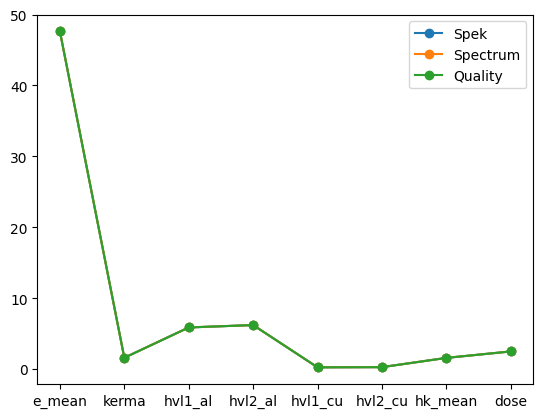

In [14]:
# Plot integral quantities comparison
df_iqs.plot(marker='o')

### Assertions

In [15]:
# Assertions for verification

# Quality attributes
assert mq.quality == 'N60'
assert mq.voltage == 60
assert mq.total_filtration == {'Al': 4.0, 'Cu': 0.6}
assert mq.distance == 100
assert mq.spek_filtration == [["Al", 4.0], ["Cu", 0.6], ["Air", 1000]]

# Spectrum
assert list(r_spek_cls['spectrum'][0]) == list(r_spectrum_cls['spectrum'][0]) == list(r_quality_cls['spectrum'][0])
assert list(r_spek_cls['spectrum'][1]) == list(r_spectrum_cls['spectrum'][1]) == list(r_quality_cls['spectrum'][1])

# Quality related integral quantities (not related to dose)
assert r_spek_cls['e_mean'] == r_spectrum_cls['e_mean'] == r_quality_cls['e_mean']
assert r_spek_cls['kerma'] == r_spectrum_cls['kerma'] == r_quality_cls['kerma']
assert r_spek_cls['hvl1_al'] == r_spectrum_cls['hvl1_al'] == r_quality_cls['hvl1_al']
assert r_spek_cls['hvl2_al'] == r_spectrum_cls['hvl2_al'] == r_quality_cls['hvl2_al']
assert r_spek_cls['hvl1_cu'] == r_spectrum_cls['hvl1_cu'] == r_quality_cls['hvl1_cu']
assert r_spek_cls['hvl2_cu'] == r_spectrum_cls['hvl2_cu'] == r_quality_cls['hvl2_cu']

# Mean conversion coefficient
assert r_spek_cls['hk_mean'] == r_spectrum_cls['hk_mean'] == r_quality_cls['hk_mean']

# Dose equivalent
assert r_spek_cls['dose'] == r_spectrum_cls['dose'] == r_quality_cls['dose']

print("All verifications passed.")

All verifications passed.


### Conclusions
- The results obtained with the Spectrum and Quality classes are consistent with those obtained with SpekPy.
- This validates the implementation of the Spectrum class and the initialization of the Spectrum instance from a named X-ray quality in the Quality class.
- The spectrum values and all integral quantities (mean energy, kerma, HVLs, mean conversion coefficient and dose equivalent) are identical across the three implementations for the reference case of N60 radiation quality.

## Verification against previous calculations

### Quality vs Spek, USpek and A1.1.7 report for all q&q
Quality class vs Spek class, USpek class and A1.1.7 report for all qualities and quantities

In [16]:
# Calculations with USpekPy
# Define x-ray beam parameters for radiation quality N-60 (filter thickness, peak kilovoltage and anode angle)
my_filters = [
  ('Al', 4),  # mm
  ('Cu', 0.6),  # mm
  ('Sn', 0),  # mm
  ('Pb', 0),  # mm
  ('Be', 0),  # mm
  ('Air', 1000)  # mm
]
my_kvp = 60  # kV
my_th = 20  # deg

# Define path to CSV file containing coefficients
my_mu_csv = '/home/u6406/PycharmProjects/metpyx/src/metpyx/data/tables/mu_tr_over_rho_air/pene_2018.csv'
my_hk_csv = '/home/u6406/PycharmProjects/metpyx/src/metpyx/data/tables/h_k/cmi_2025/h_star_10.csv'

df = pd.read_csv(my_hk_csv)
my_hk_e, my_hk_v =(np.array(df['E keV']), np.array(df['hK 0 Sv/Gy']))

mask_hk = my_hk_v != 0
filtered_hk_energies = my_hk_e[mask_hk]
filtered_hk_values = my_hk_v[mask_hk]

# Initialize an SpeckWrapper object and add filters
spectrum = usp.SpekWrapper(kvp=my_kvp, th=my_th)
spectrum.multi_filter(my_filters)

# Calculate integral quantities
r_uspek_cls = {
'hvl1_al': spectrum.get_hvl1(),
'hvl2_al': spectrum.get_hvl2(),
'hvl1_cu' : spectrum.get_hvl1(matl='Cu'),
'hvl2_cu' : spectrum.get_hvl2(matl='Cu'),
'e_mean' : spectrum.get_mean_energy(),
'kerma' : spectrum.get_air_kerma(mass_transfer_coefficients=my_mu_csv),
'hk_mean' : spectrum.get_mean_conversion_coefficient(mass_transfer_coefficients=my_mu_csv, conversion_coefficients=(filtered_hk_energies, filtered_hk_values))
}

In [17]:
# Reported in A1.1.7 report for all qualities and quantities
r_a117 = {'hvl1_al': 5.8582747051770605, 'hvl2_al': 6.196968255804022, 'hvl1_cu': 0.23236896040944352,
        'hvl2_cu': 0.25978939890001607, 'e_mean': 47.63300484905786, 'kerma': 1.5821240129760867,
        'hk_mean': 1.5652667635344528}

In [18]:
# Create a DataFrame to compare integral quantities values
df_iqs2 = pd.DataFrame({'Spek': r_spek_cls, 'Spectrum': r_spectrum_cls, 'Quality': r_quality_cls, 'USpek': r_uspek_cls, 'A117': r_a117})
df_iqs2.drop(['spectrum', 'dose'], axis=0, inplace=True)
rel_diff2 = df_iqs2.sub(df_iqs2['Spek'], axis=0).div(df_iqs2['Spek'], axis=0).mul(100)
max_rel_diff2 = rel_diff2.abs().max()

In [19]:
# Print values comparison
df_iqs2

,Spek,Spectrum,Quality,USpek,A117
e_mean,47.633005,47.633005,47.633005,47.633005,47.633005
kerma,1.582124,1.582124,1.582124,1.564530,1.582124
hvl1_al,5.858275,5.858275,5.858275,5.858275,5.858275
hvl2_al,6.196968,6.196968,6.196968,6.196968,6.196968
hvl1_cu,0.232369,0.232369,0.232369,0.232369,0.232369
hvl2_cu,0.259789,0.259789,0.259789,0.259789,0.259789
hk_mean,1.565267,1.565267,1.565267,1.565267,1.565267


In [20]:
# Print relative differences
rel_diff2

,Spek,Spectrum,Quality,USpek,A117
e_mean,0.0,0.0,0.0,0.0,0.0
kerma,0.0,0.0,0.0,-1.112055,0.0
hvl1_al,0.0,0.0,0.0,0.0,0.0
hvl2_al,0.0,0.0,0.0,0.0,0.0
hvl1_cu,0.0,0.0,0.0,0.0,0.0
hvl2_cu,0.0,0.0,0.0,0.0,0.0
hk_mean,0.0,0.0,0.0,-0.0,-0.0


In [21]:
# Print maximum relative difference
max_rel_diff2

Spek             0.0
Spectrum         0.0
Quality          0.0
USpek       1.112055
A117             0.0
dtype: object

In [22]:
# Check for non-zero relative differences
if (rel_diff2 != 0).any().any():
    warnings.simplefilter('always', UserWarning)           # ensure warning is shown
    warnings.warn('Some elements are different than 0', UserWarning, stacklevel=2)

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Some elements are different than 0
  exec(code_obj, self.user_global_ns, self.user_ns)


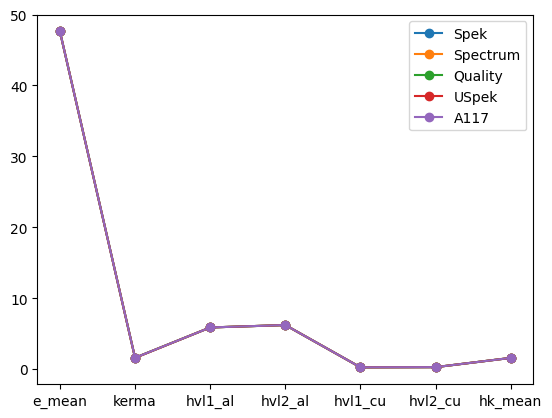

In [23]:
# Plot values comparison
df_iqs2.plot(marker='o')

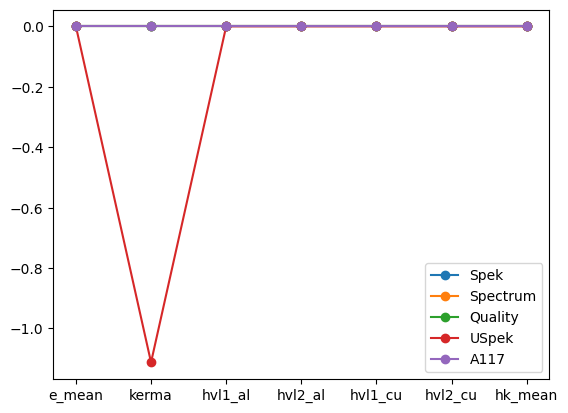

In [24]:
# Plot relative differences
rel_diff2.plot(marker='o')

### Conclusions
- The results obtained with the Quality class are consistent with those obtained with SpekPy, USpekPy and reported values in CIEMAT A1.1.7 for the reference case of N60 radiation quality.
- The spectrum values and all integral quantities (mean energy, kerma, HVLs, mean conversion coefficient) are identical across the three implementations for the reference case of N60 radiation quality.
- The exception is the value for air kerma calculated using USpek class.

### Quality class vs reported A1.1.7 for selected q&q
Comparison between MetPyX Quality class and reported values in CIEMAT A1.1.7 for selected qualities and quantities (Jaroslav Excel in email *"GuideRadPROS A1.1.7: preliminary results for A1.1.7 - kV variations"*).

In [25]:
# Calculations with Quality class for selected qualities and quantities
q1 = Quality("N30", th=20)
q2 = Quality("N40", th=20)
q3 = Quality("N60", th=20)
q4 = Quality("H60", th=20)
q5 = Quality("N250", th=20)

r_quality_cls_2 = {
    ('N30', 'h_star_10', 0): q1.get_hk_mean('h_star_10', 0),
    ('N30', 'h_p_07_slab', 0): q1.get_hk_mean('h_p_07_slab', 0),
    ('N30', 'h_p_07_rod', 0): q1.get_hk_mean('h_p_07_rod', 0),
    ('N40', 'h_star_10', 0): q2.get_hk_mean('h_star_10', 0),
    ('N40', 'h_p_07_slab', 0): q2.get_hk_mean('h_p_07_slab', 0),
    ('N40', 'h_p_07_rod', 0): q2.get_hk_mean('h_p_07_rod', 0),
    ('N60', 'h_star_10', 0): q3.get_hk_mean('h_star_10', 0),
    ('N60', 'h_p_07_slab', 0): q3.get_hk_mean('h_p_07_slab', 0),
    ('N60', 'h_p_07_rod', 0): q3.get_hk_mean('h_p_07_rod', 0),
    ('H60', 'h_star_10', 0): q4.get_hk_mean('h_star_10', 0),
    ('H60', 'h_p_07_slab', 0): q4.get_hk_mean('h_p_07_slab', 0),
    ('H60', 'h_p_07_rod', 0): q4.get_hk_mean('h_p_07_rod', 0),
    ('N250', 'h_star_10', 0): q5.get_hk_mean('h_star_10', 0),
    ('N250', 'h_p_07_slab', 0): q5.get_hk_mean('h_p_07_slab', 0),
    ('N250', 'h_p_07_rod', 0): q5.get_hk_mean('h_p_07_rod', 0),
}

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized me

In [26]:
# Reported values in CIEMAT A1.1.7 for selected qualities and quantities
r_a117_2 = {
    ('N30', 'h_star_10', 0): 0.806885558316363,
    ('N30', 'h_p_07_slab', 0): 1.11448855756614,
    ('N30', 'h_p_07_rod', 0): 1.04324004559772,
    ('N40', 'h_star_10', 0): 1.17593033663222,
    ('N40', 'h_p_07_slab', 0): 1.28317484599388,
    ('N40', 'h_p_07_rod', 0): 1.07520090386855,
    ('N60', 'h_star_10', 0): 1.5651644658369,
    ('N60', 'h_p_07_slab', 0): 1.55514905850875,
    ('N60', 'h_p_07_rod', 0): 1.11462960540175,
    ('H60', 'h_star_10', 0): 1.1916262091482,
    ('H60', 'h_p_07_slab', 0): 1.31396159889724,
    ('H60', 'h_p_07_rod', 0): 1.07785061763632,
    ('N250', 'h_star_10', 0): 1.38786367074322,
    ('N250', 'h_p_07_slab', 0): 1.42476508709555,
    ('N250', 'h_p_07_rod', 0): 1.14923205051759,
}

In [27]:
# Create a DataFrame to compare integral quantities values
df_iqs3 = pd.DataFrame({'Quality': r_quality_cls_2, 'A117': r_a117_2})
rel_diff3 = df_iqs3.sub(df_iqs3['A117'], axis=0).div(df_iqs3['A117'], axis=0).mul(100)
max_rel_diff3 = rel_diff3.abs().max()

In [28]:
# Print values comparison
df_iqs3

Quality      A117
N30  h_star_10   0  0.807858  0.806886
     h_p_07_slab 0  1.116090  1.114489
     h_p_07_rod  0  1.041964  1.043240
N40  h_star_10   0  1.178619  1.175930
     h_p_07_slab 0  1.285639  1.283175
     h_p_07_rod  0  1.074724  1.075201
N60  h_star_10   0  1.565267  1.565164
     h_p_07_slab 0  1.556850  1.555149
     h_p_07_rod  0  1.112757  1.114630
H60  h_star_10   0  1.193246  1.191626
     h_p_07_slab 0  1.315891  1.313962
     h_p_07_rod  0  1.076723  1.077851
N250 h_star_10   0  1.388630  1.387864
     h_p_07_slab 0  1.422809  1.424765
     h_p_07_rod  0  1.147228  1.149232

In [29]:
# Print relative differences
rel_diff3

Quality  A117
N30  h_star_10   0  0.120469   0.0
     h_p_07_slab 0  0.143669   0.0
     h_p_07_rod  0 -0.122321   0.0
N40  h_star_10   0  0.228606   0.0
     h_p_07_slab 0  0.192058   0.0
     h_p_07_rod  0 -0.044361   0.0
N60  h_star_10   0  0.006536   0.0
     h_p_07_slab 0  0.109390   0.0
     h_p_07_rod  0 -0.167979   0.0
H60  h_star_10   0  0.135951   0.0
     h_p_07_slab 0  0.146875   0.0
     h_p_07_rod  0 -0.104609   0.0
N250 h_star_10   0  0.055206   0.0
     h_p_07_slab 0 -0.137322   0.0
     h_p_07_rod  0 -0.174397   0.0

In [30]:
# Print maximum relative difference
max_rel_diff3

Quality    0.228606
A117       0.000000
dtype: float64

In [31]:
# Check for non-zero relative differences
if (rel_diff2 != 0).any().any():
    warnings.simplefilter('always', UserWarning)           # ensure warning is shown
    warnings.warn('Some elements are different than 0', UserWarning, stacklevel=2)

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Some elements are different than 0
  exec(code_obj, self.user_global_ns, self.user_ns)


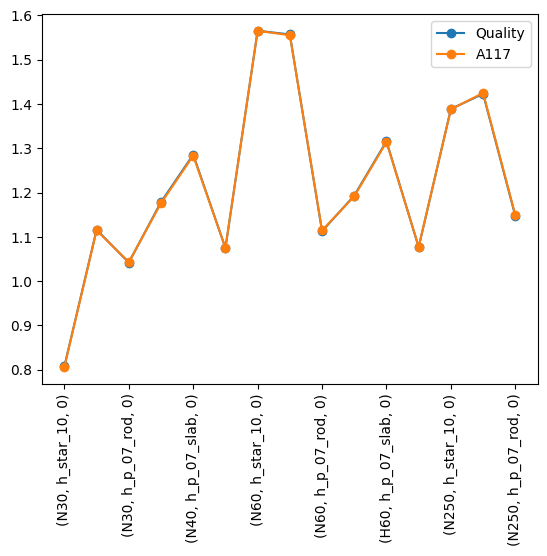

In [32]:
# Plot values comparison
df_iqs3.plot(marker='o', rot=90)

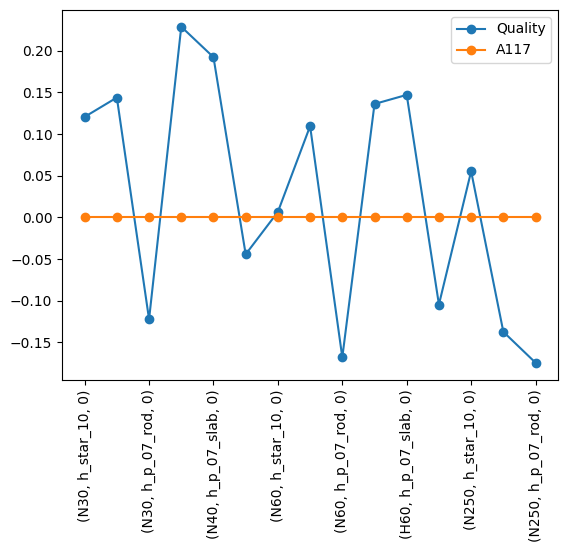

In [33]:
# Plot relative differences
rel_diff3.plot(marker='o', rot=90)

### Conclusions
- The results obtained for the mean air-kerma-to-dose conversion coefficients with the Quality class are consistent with those reported in CIEMAT A1.1.7 for the selected qualities and quantities.
- Relative are below 0.3% for all cases.

### Quality class vs A1.1.7 report for all q&q

In [34]:
# Using Quality class

# Get all qualities and quantities available in MetPyX
qls = Qualities()
qts = OperationalQuantities()
qualities = qls.get_all_qualities()
quantities = qts.get_all_quantities()

# Get mean conversion coefficient for all qualities and quantities
metpyx_results = {}
for quality in qualities:
    q = Quality(quality, th=20)
    metpyx_results[quality] = {}
    for quantity in quantities:
        for angle in qts.get_irradiation_angles(quantity):
            print(quality, quantity, angle)
            metpyx_results[quality][(f'{quantity}', f'{angle}')] = q.get_hk_mean(quantity, angle)

# Build a DataFrame to compare mean conversion coefficient values
df_metpyx = pd.DataFrame(metpyx_results).T

/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:103: UserWarning: Zeros found in h_k values; removed for interpolation.
  warnings.warn("Zeros found in h_k values; removed for interpolation.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:120: UserWarning: NaN values found in interpolated h_k.
  warnings.warn("NaN values found in interpolated h_k.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:103: UserWarning: Zeros found in h_k values; removed for interpolation.
  warnings.warn("Zeros found in h_k values; removed for interpolation.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:120: UserWarning: NaN values found in interpolated h_k.
  warnings.warn("NaN values found in interpolated h_k.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:103: UserWarning: Zeros found in h_k values; removed for interpolation.
  warnings.warn("Zeros found in h_k values; removed for interpolation.")
/home/u6406/PycharmProjects/m

In [35]:
# From A1.1.7 report for all qualities and quantities
a117_file = '/home/u6406/PycharmProjects/metpyx/notebooks/a117_report_all_qq_hk.csv'
df_a117 = pd.read_csv(a117_file, index_col=0)

In [36]:
# Modifying MetPyX DataFrame for comparison
df_metpyx = pd.DataFrame(metpyx_results).T
df_metpyx = df_metpyx.T.reset_index()
quantities_map = {
    'h_p_07_pill':'Hp(0.07, pillar)',
    'h_p_07_rod':'Hp(0.07, rod)',
    'h_p_07_slab':'Hp(0.07, slab)',
    'h_p_10_slab':'Hp(10, slab)',
    'h_p_3_cyl':'Hp(3, cyl)',
    'h_prime_07':'H_prime(0.07)',
    'h_prime_3':'H_prime(3)',
    'h_star_10':'H*(10)'
}
df_metpyx['level_0']=df_metpyx['level_0'].replace(quantities_map)
df_metpyx['level_1'] = df_metpyx['level_1'].add('º')
df_metpyx['Operational quantity'] = df_metpyx['level_0'].str.cat(df_metpyx['level_1'], sep=' ')
df_metpyx.drop(['level_0', 'level_1'], axis=1, inplace=True)
df_metpyx.set_index('Operational quantity', inplace=True)

assert len(df_metpyx.columns) == len(df_a117.columns)
assert len(df_metpyx.index) == len(df_a117.index)
assert set(df_metpyx.columns) == set(df_a117.columns)
assert set(df_metpyx.index) == set(df_a117.index)

In [37]:
# Create a DataFrame to compare integral quantities values
rel_diff4 = df_metpyx.sub(df_a117).div(df_a117).mul(100)
max_rel_diff4 = rel_diff4.abs().max().max()

In [38]:
# Print relative differences
rel_diff4

,H10,H100,H150,H20,H200,H250,H280,H30,H300,H350,...,N80,W110,W150,W200,W250,W30,W300,W40,W60,W80
Operational quantity,,,,,,,,,,,,,,,,,,,,,
H*(10) 0º,7.826342e-12,-8.446685e-14,-5.300526e-14,-1.639086e-14,-4.107772e-14,5.725851e-14,1.189955e-13,1.448670e-14,-1.337116e-13,-1.539281e-14,...,-2.542886e-14,7.729829e-14,-6.804111e-14,-2.914544e-14,-1.538360e-14,-3.244063e-14,0.000000e+00,2.235330e-14,0.000000e+00,5.370167e-14
H_prime(0.07) 0º,-2.476946e-14,-1.490936e-14,-1.289102e-13,-2.317047e-14,2.932848e-14,-1.212294e-13,7.795948e-14,-2.182074e-14,-1.402646e-13,3.202490e-14,...,-1.392761e-14,1.402658e-14,1.019894e-13,7.666682e-14,-7.992903e-14,0.000000e+00,0.000000e+00,3.762759e-14,0.000000e+00,0.000000e+00
H_prime(0.07) 15º,0.000000e+00,-8.968627e-14,0.000000e+00,2.319747e-14,-1.468272e-14,6.065281e-14,7.797008e-14,2.183875e-14,-1.714663e-13,4.802774e-14,...,-1.396544e-14,2.811218e-14,-2.917166e-14,6.134905e-14,-1.598189e-14,0.000000e+00,6.582365e-14,5.652244e-14,3.128274e-14,0.000000e+00
H_prime(0.07) 180º,NaN,3.133078e-13,1.079938e-13,NaN,-4.119621e-14,5.263426e-14,1.416457e-13,0.000000e+00,-2.989671e-13,2.138229e-13,...,3.290952e-14,1.866264e-13,-1.958059e-14,0.000000e+00,2.959841e-14,-1.547107e-14,1.333983e-14,6.888065e-12,7.077796e-13,2.465096e-13
H_prime(0.07) 30º,0.000000e+00,-6.025767e-14,-7.220713e-14,-2.328575e-14,-1.179042e-13,7.594514e-14,3.119122e-14,0.000000e+00,-2.338775e-13,3.198674e-14,...,1.408031e-14,7.072925e-14,1.463506e-14,3.069337e-14,-1.117356e-13,-2.069789e-14,0.000000e+00,3.785626e-14,1.576838e-14,4.394009e-14
H_prime(0.07) 45º,-1.285540e-14,-4.583547e-14,-7.299599e-14,1.174036e-14,-5.932914e-14,-1.066001e-13,1.247242e-13,-2.201511e-14,-2.338649e-13,9.573455e-14,...,1.428678e-14,2.861042e-14,4.415296e-14,9.213626e-14,-3.183756e-14,0.000000e+00,1.633904e-14,3.820562e-14,3.200999e-14,0.000000e+00
H_prime(0.07) 60º,-1.355424e-14,-4.693950e-14,1.486539e-14,1.196414e-14,0.000000e+00,1.530000e-14,4.677070e-14,-1.113500e-14,-2.183569e-13,-1.590197e-14,...,0.000000e+00,2.914270e-14,2.971827e-14,3.076139e-14,-7.929123e-14,2.107144e-14,-1.622066e-14,3.886484e-14,8.209814e-14,1.525555e-14
H_prime(0.07) 75º,0.000000e+00,-8.154547e-14,-4.604796e-14,-1.270488e-14,1.531196e-14,-3.097189e-14,3.134217e-14,-2.297025e-14,-3.137161e-13,7.951162e-14,...,-1.524171e-14,1.504997e-14,-4.544748e-14,4.650247e-14,-1.109773e-13,2.162379e-14,-1.612915e-14,2.009352e-14,1.717628e-14,1.593767e-14
H_prime(0.07) 90º,3.420156e-13,-7.600188e-14,1.734287e-14,1.283021e-14,-6.776296e-14,0.000000e+00,0.000000e+00,-2.149120e-14,-1.182343e-13,6.780690e-14,...,3.493665e-14,3.393984e-14,-3.340900e-14,3.352884e-14,-6.763201e-14,-1.522635e-14,1.703017e-14,3.815808e-14,2.034378e-14,1.850960e-14


In [39]:
# Print maximum relative difference
max_rel_diff4

np.float64(5.8202274155452373e-11)

In [40]:
# Check for non-zero relative differences
if (rel_diff4 != 0).any().any():
    warnings.simplefilter('always', UserWarning)  # ensure warning is shown
    warnings.warn('Some elements are different than 0', UserWarning, stacklevel=2)

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Some elements are different than 0
  exec(code_obj, self.user_global_ns, self.user_ns)


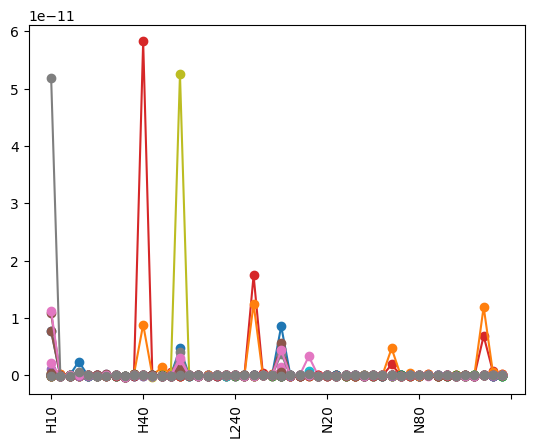

In [41]:
# Plot relative differences
rel_diff4.T.plot(marker='o', rot=90, legend=False)

### Conclusions
- The results obtained for the mean air-kerma-to-dose conversion coefficients with the Quality class are consistent with those reported in CIEMAT A1.1.7 for all qualities and quantities.
- Relative differences are below 6*10^-11 for all cases.

## Notes

### On SpekPy spectrum parameters

To correctly calculate the mean conversion coefficient, the parameters for spekpy get_spectrum() method must be configured with edges=False, flu=True, diff=False, sig=False. This means energy bins are defined at the mid-bin values, fluence is returned, returned fluence is non-differential in energy (1/cm²), the calculated spectrum is returned without smoothing. Only the diff parameter is different from the default value (see method API in https://bitbucket.org/spekpy/spekpy_release/wiki/Function%20glossary).

### On SpekPy air thickness and distance
How to calculate exactly at 1 m and 2.5 m?
To be precise, air thickness should be measurement distance - total filtration thickness.
There is a parameter in spekpy to set measurement distance.
In order to compare with previous results I am not going  to change the approach, but I should look into this later.

In [42]:
# On SpekPy air thickness and distance

s1 = sp.Spek(kvp=60)
s1.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 1000]])
kerma1 = s1.get_kerma()

s2 = sp.Spek(kvp=60, z=100)
s2.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 1000]])
kerma2 = s2.get_kerma()

s3 = sp.Spek(kvp=60, z=250)
s3.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 2500]])
kerma3 = s3.get_kerma()

s4 = sp.Spek(kvp=60)
s4.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", 2500]])
kerma4 = s4.get_kerma()

s5 = sp.Spek(kvp=60)
distance = s5.state.spectrum_parameters.z
total_filtration_thickness = sum(item[1] for item in [["Al", 4.0], ["Cu", 0.6]])
air_thickness1 = distance*10 - total_filtration_thickness
s5.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", air_thickness1]])
kerma5 = s5.get_kerma()

s6 = sp.Spek(kvp=60, z=250)
distance = s6.state.spectrum_parameters.z
total_filtration_thickness = sum(item[1] for item in [["Al", 4.0], ["Cu", 0.6]])
air_thickness2 = distance*10 - total_filtration_thickness
s6.multi_filter([["Al", 4.0], ["Cu", 0.6], ["Air", air_thickness2]])
kerma6 = s6.get_kerma()

print('Default distance 100?', kerma1, kerma2)
print('Distance 100 vs 250 using z parameter:', kerma1, kerma3)
print('Distance 100 vs 250 using air filter:', kerma1, kerma4)
print(f'Air thickness equal to {1000} vs {air_thickness1}:', kerma1, kerma5)
print(f'Air thickness equal to {2500} vs {air_thickness2}:', kerma3, kerma6)

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized me

In [43]:
# Calculating kerma at 1 m and 2.5 m

q1 = Quality("N60")
kerma7 = q1.get_kerma()

q2 = Quality("N60", z=250)
kerma8 = q2.get_kerma()

print('Kerma at 1 m, spekpy vs metpyx:', kerma1, kerma7)
print('Kerma at 2.5 m, spekpy vs metpyx:', kerma3, kerma8)

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized me

In [44]:
# Calculating mean conversion coefficient at 1 m and 2.5 m
q100 = Quality("N60", th=20, z=100)
q250 = Quality("N60", th=20, z=250)

mean_hk_100 = q100.get_hk_mean('h_star_10', 0)
mean_hk_250 = q250.get_hk_mean('h_star_10', 0)

print('Mean h_k at 1 m vs 2.5 m:', mean_hk_100, mean_hk_250, abs(mean_hk_250-mean_hk_100)/mean_hk_100, '% difference')

/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  char_kx[i,:] = divide(char_kx[i,:],attn_factor,where=attn_factor>0)
/home/u6406/PycharmProjects/metpyx/.venv/lib/python3.12/site-packages/spekpy/SpekAniso.py:877: UserWarning: 'where' used without 'out', expect unitialized me